In [1]:
import numpy as np 
import matplotlib.pyplot as plt
import pickle 
from centralized_solution import Cov, Cov2, solve,plot_me


C:\Users\BONETTI\AppData\Local\Temp\ipykernel_17248\2379282772.py:13: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  x_full, y_full = pickle.load(f)


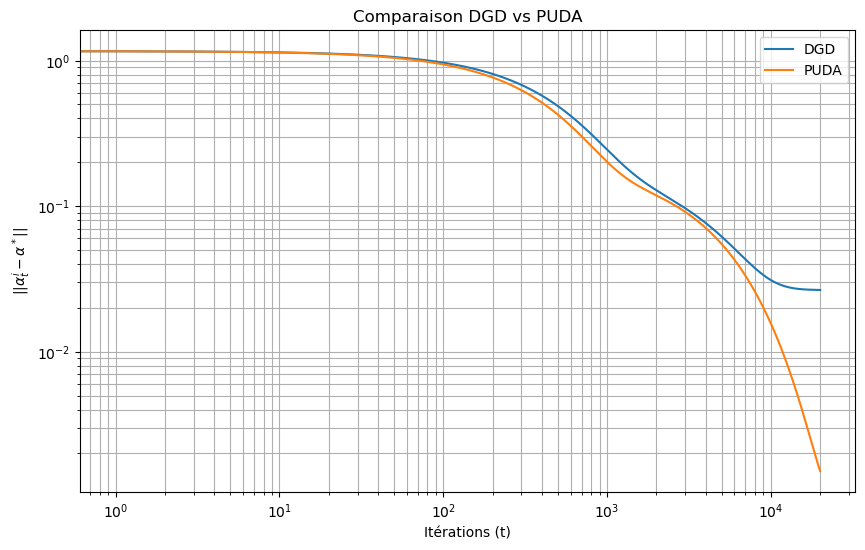

In [9]:
#on va appliquer avce ce premier graphe le decentralized gradient descent 
#Start with xi0 P Rn at each device i and a stepsize sequence tαkukP
# 2. Sélection des points 
n, m, a = 100, 20, 5


sigma = 0.5      # Bruit 
nu = 1.0         # Régularisation 
n_iter = 20000   # Nombre d'itérations

# 1. Chargement et préparation
with open('first_database.pkl', 'rb') as f:
    x_full, y_full = pickle.load(f)

x = x_full[:n]
y = y_full[:n]

sel = np.arange(n)
ind = np.random.choice(sel, m, replace=False)
x_m = x[ind]

# on charge les matrices Knm et Kmm 
Kmm=Cov(x_m)
Knm=Cov2(x,x_m)

# solution pour le kernel ridge est un alpha * 
a_star= (sigma**2)*Kmm + Knm.T @ Knm + nu*np.eye(m)
b_star=Knm.T@y
alpha_star=np.linalg.solve(a_star,b_star)


#construction de la matrice W 
#graphe complet 
W3 = np.ones((a, a)) / a



#on va débuter le DGD et PUDA 
# 1. on initialise 
alpha_dgd = np.zeros((a,m)) # sequence des alpha necessaires pour le calcul 
alpha_puda = np.zeros((a,m))
y_puda= np.zeros((a,m))


#matrices B , A et C pour exact diffisuion 
C=0
B= 0.5* (np.eye(a)-W3)
A_bar= 0.5* (np.eye(a)+W3)



#terme non lisse R(w) 
def prox(w,mu):
    return np.sign(w) * np.maximum(np.abs(w)-mu, 0)

lbd=0.0001
    




erreur_dgd=[]
erreur_puda=[]

#pas 
eta=0.001

for t in range (n_iter):
    
    #on fait les etapes pour DGD 
    new_alpha= np.zeros_like(alpha_dgd)
    for i in range (a): #pour chaque agent 
        idx_loc = range(i*20, (i+1)*20)
        Ki = Knm[idx_loc, :]
        yi = y[idx_loc]
        
        grad_i= (sigma**2/a) * Kmm @ alpha_dgd[i] + Ki.T @ (Ki @ alpha_dgd[i] - yi) + (nu/a) * alpha_dgd[i]
        new_alpha[i] = W3[i, :] @ alpha_dgd - eta * grad_i
    alpha_dgd= new_alpha
    erreur_dgd.append(np.linalg.norm(np.mean(alpha_dgd, axis=0) - alpha_star))

    
    
    #on fait pour GT 
    new_alpha_2= np.zeros_like(alpha_puda)
    new_y= np.zeros_like(y_puda)
    z=np.zeros_like(alpha_puda)
    for i in range (a): #pour chaque agent 
        idx_loc = range(i*20, (i+1)*20)
        Ki = Knm[idx_loc, :]
        yi = y[idx_loc]
        
        grad_i= (sigma**2/a) * Kmm @ alpha_puda[i] + Ki.T @ (Ki @ alpha_puda[i] - yi) + (nu/a) * alpha_puda[i]
        z[i]= alpha_puda[i] - eta * grad_i - B[i,:] @ y_puda 
    new_y = y_puda + B@ z
    tmp= A_bar @z 
    
    for i in range (a):
        new_alpha_2[i]= prox(tmp[i], eta*lbd)
        
        
    alpha_puda=new_alpha_2
    y_puda= new_y
    
    erreur_puda.append(np.linalg.norm(np.mean(alpha_puda, axis=0) - alpha_star))
    
    
plt.figure(figsize=(10, 6))
plt.loglog(erreur_dgd, label='DGD')
plt.loglog(erreur_puda, label='PUDA')
plt.xlabel('Itérations (t)')
plt.ylabel(r'$||\alpha_t^i - \alpha^*||$')
plt.title('Comparaison DGD vs PUDA')
plt.legend()
plt.grid(True, which="both", ls="-")   
        


In [10]:
erreur_puda[-1]

np.float64(0.0015131721199286754)

In [11]:
erreur_dgd[-1]

np.float64(0.026553454377827627)